# 02 — Visualizing the DRB Stream Temperature Sites

This notebook builds intuition about the data at all 5 monitoring sites:
- How stream temperatures vary over time and across sites
- Seasonal patterns
- The meteorological and reservoir-release drivers
- How infilled vs observed targets are distributed in time
- Feature–target correlations

**Prerequisite**: `.npz` files downloaded from Google Drive into `data/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

DATA_DIR = '../../public/eacvi-fhnn-data/site_wise_data_static_infilled/sequence_length_360'
SITE_IDS = [1573, 1571, 1565, 1450, 1641]
SITE_LABELS = {
    1573: '1573 (Cannonsville+Pepacton)',
    1571: '1571 (Cannonsville)',
    1565: '1565 (Cannonsville)',
    1450: '1450 (Pepacton)',
    1641: '1641 (Neversink)',
}

# 15 input features; col 14 is stream_temp (ar1), masked at forecast steps
FEATURE_NAMES = [
    'tmin', 'tmax', 'srad', 'pr', 'vs', 'rmax', 'rmin', 'rmean',
    'spillway', 'releases',
    'seg_slope', 'seg_elev', 'seg_width', 'seg_length',
    'stream_temp'
]

# Fine-tuning period start date (used to reconstruct a date axis)
FINETUNE_START = pd.Timestamp('1985-05-01')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

In [3]:
# Load all sites
sites = {}
for sid in SITE_IDS:
    d = np.load(f'{DATA_DIR}/{sid}.npz', allow_pickle=True)
    X = d['finetune_X'].astype(np.float32)
    Y = d['finetune_Y'].astype(np.float32)
    mask = d['finetune_Y_mask'].astype(bool)
    dates = pd.date_range(start=FINETUNE_START, periods=len(Y), freq='D')
    sites[sid] = {'X': X, 'Y': Y, 'mask': mask, 'dates': dates}

print(f'Loaded {len(sites)} sites. Finetune rows per site:')
for sid, s in sites.items():
    print(f'  {sid}: {len(s["Y"])} rows  ({s["dates"][0].date()} to {s["dates"][-1].date()})')

Loaded 5 sites. Finetune rows per site:
  1573: 13132 rows  (1985-05-01 to 2021-04-13)
  1571: 13132 rows  (1985-05-01 to 2021-04-13)
  1565: 13132 rows  (1985-05-01 to 2021-04-13)
  1450: 13132 rows  (1985-05-01 to 2021-04-13)
  1641: 13132 rows  (1985-05-01 to 2021-04-13)


## 1. Stream temperature over time — all 5 sites

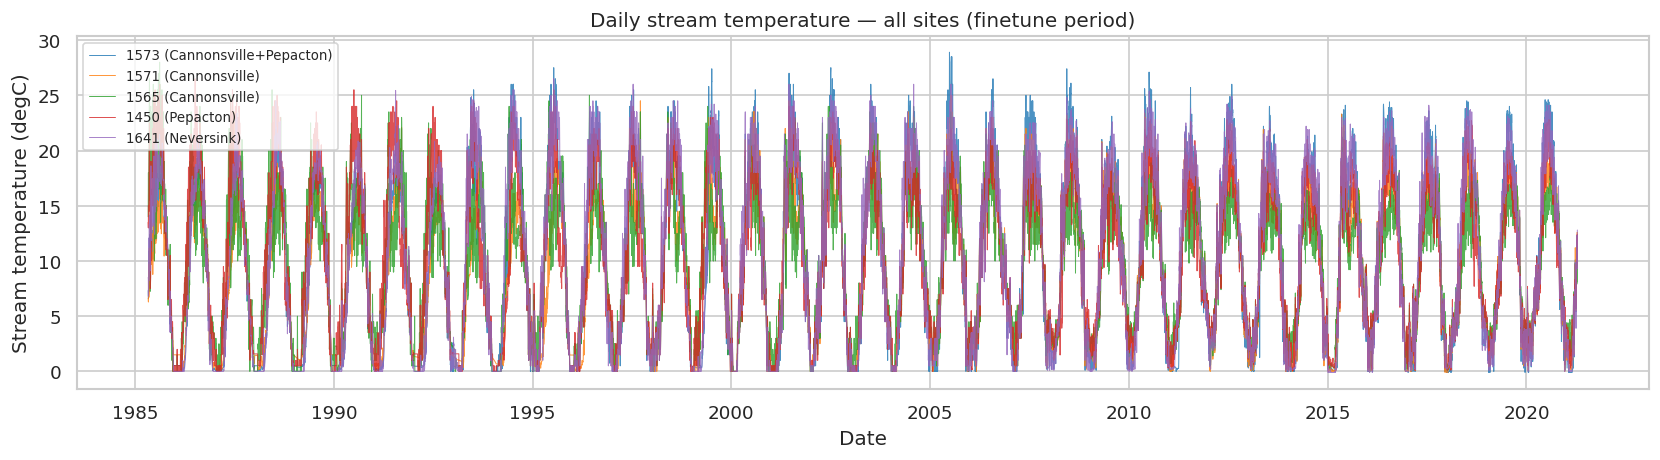

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
for sid, s in sites.items():
    ax.plot(s['dates'], s['Y'], linewidth=0.6, alpha=0.8, label=SITE_LABELS[sid])
ax.set_title('Daily stream temperature — all sites (finetune period)')
ax.set_ylabel('Stream temperature (degC)')
ax.set_xlabel('Date')
ax.legend(fontsize=8, loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 2. Recent 3 years — zoomed in

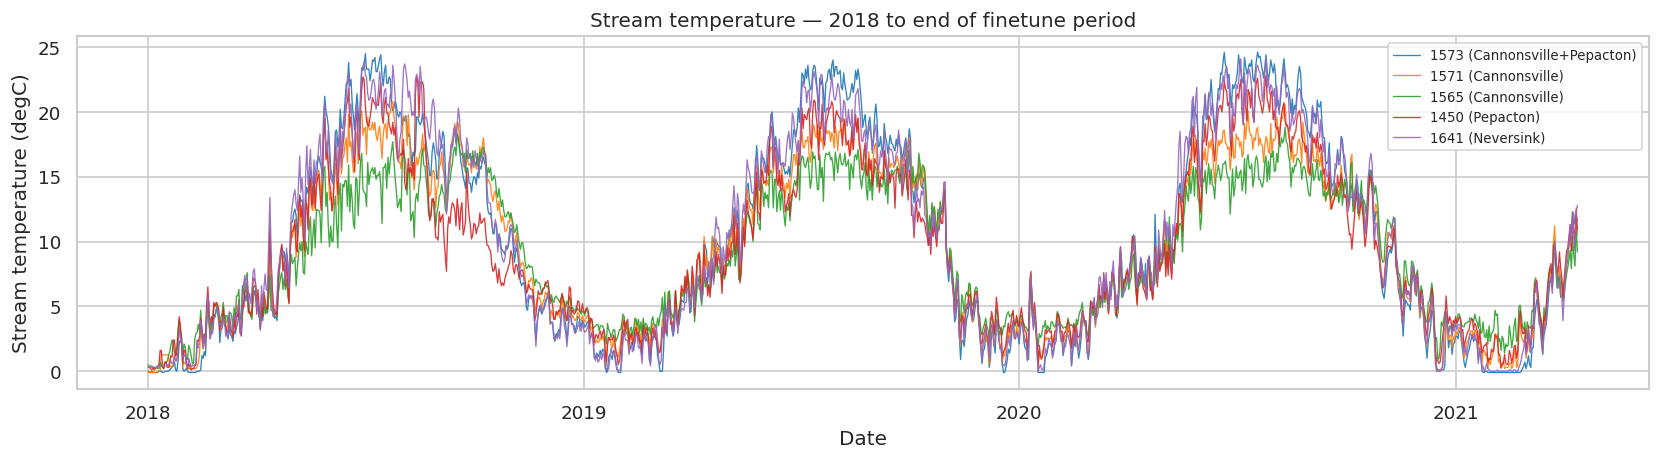

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
zoom_start = pd.Timestamp('2018-01-01')
for sid, s in sites.items():
    idx = s['dates'] >= zoom_start
    ax.plot(s['dates'][idx], s['Y'][idx], linewidth=0.8, alpha=0.9, label=SITE_LABELS[sid])
ax.set_title('Stream temperature — 2018 to end of finetune period')
ax.set_ylabel('Stream temperature (degC)')
ax.set_xlabel('Date')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 3. Seasonal patterns — temperature by month

/tmp/ipykernel_3029718/1736227430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_3029718/1736227430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_3029718/1736227430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_3029718/1736227430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_3029718/1736227430.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() ha

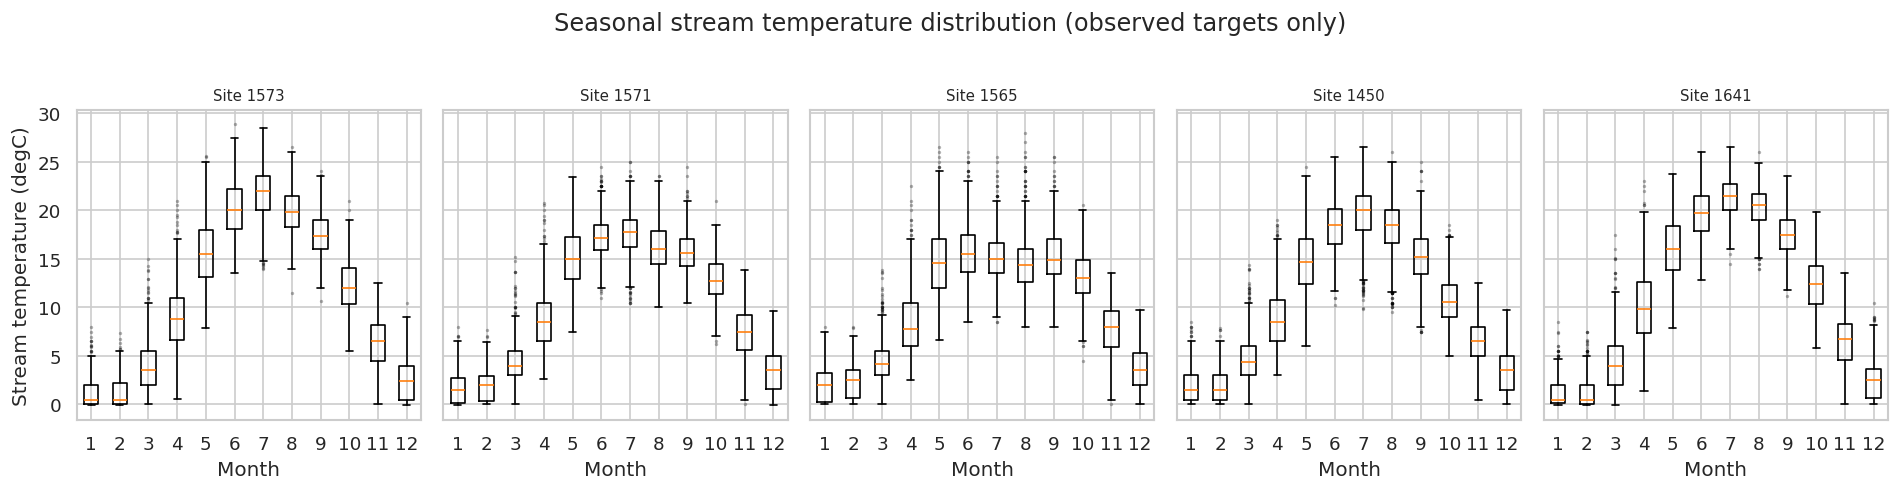

In [6]:
fig, axes = plt.subplots(1, len(SITE_IDS), figsize=(16, 4), sharey=True)
for ax, sid in zip(axes, SITE_IDS):
    s = sites[sid]
    df = pd.DataFrame({'temp': s['Y'], 'month': s['dates'].month})
    df_obs = df[~s['mask']]  # observed targets only
    ax.boxplot(
        [df_obs[df_obs['month'] == m]['temp'].values for m in range(1, 13)],
        labels=[str(m) for m in range(1, 13)],
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3}
    )
    ax.set_title(f'Site {sid}', fontsize=9)
    ax.set_xlabel('Month')
axes[0].set_ylabel('Stream temperature (degC)')
fig.suptitle('Seasonal stream temperature distribution (observed targets only)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Meteorological drivers — site 1573

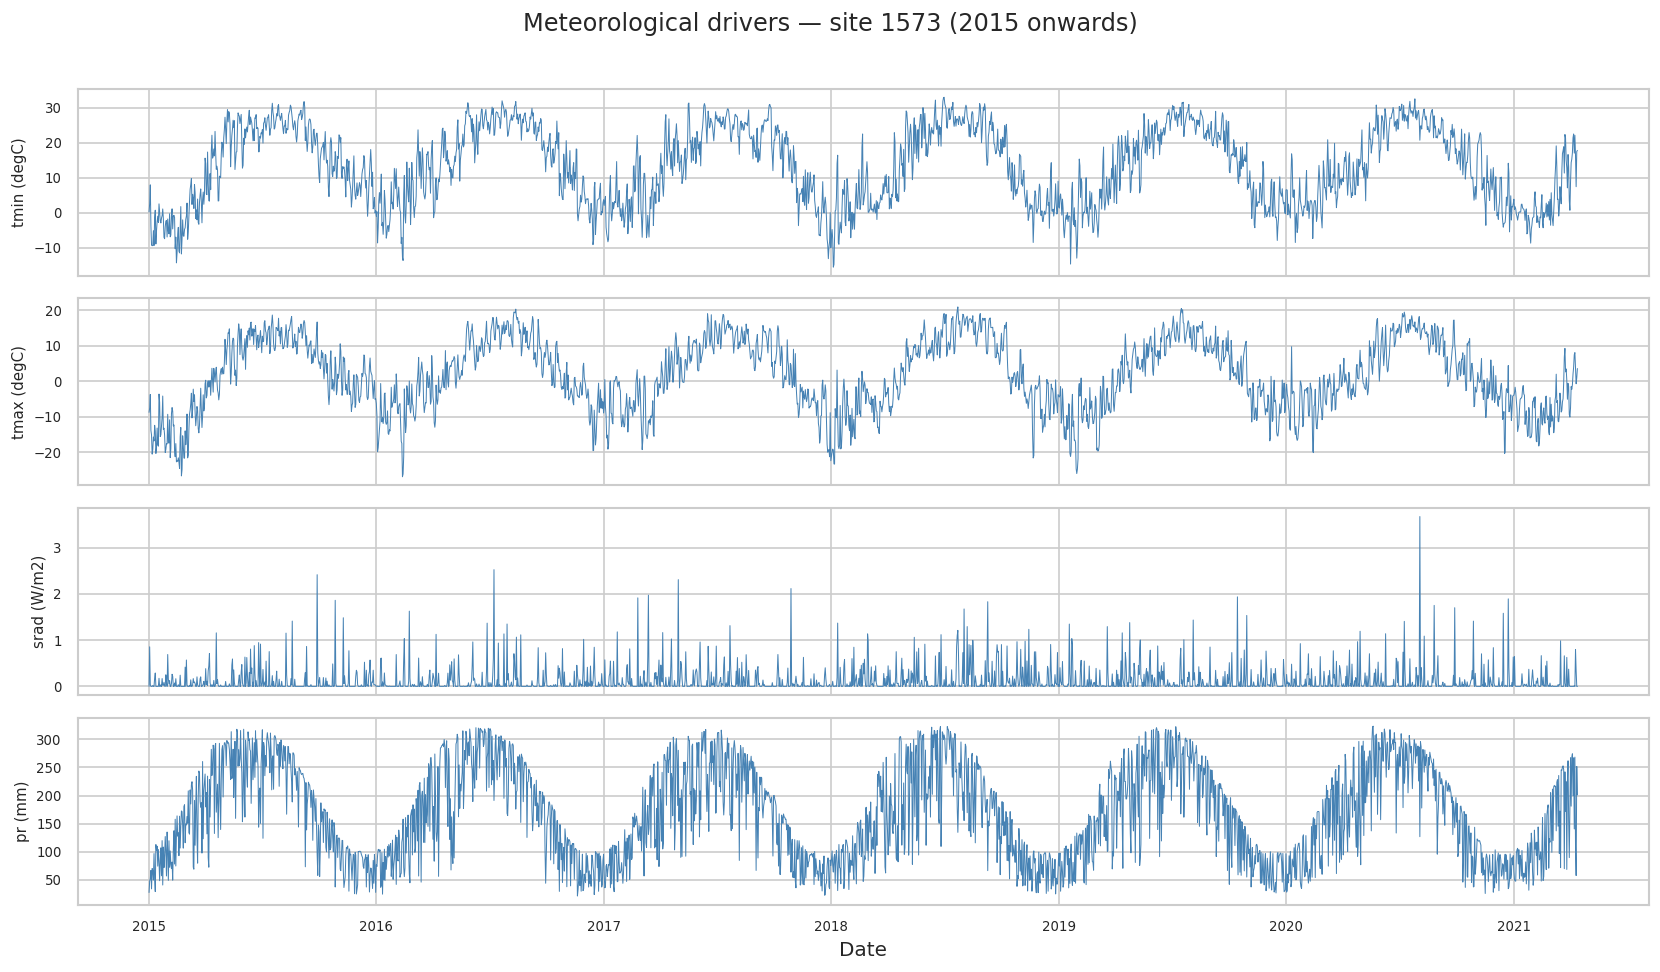

In [7]:
sid = 1573
s = sites[sid]
zoom = s['dates'] >= pd.Timestamp('2015-01-01')
dates_z = s['dates'][zoom]
X_z = s['X'][zoom]

# cols 0-3: tmin, tmax, srad, pr
driver_cols = {'tmin': 0, 'tmax': 1, 'srad': 2, 'pr': 3}
units = ['degC', 'degC', 'W/m2', 'mm']
fig, axes = plt.subplots(len(driver_cols), 1, figsize=(14, 8), sharex=True)
for ax, (name, col), unit in zip(axes, driver_cols.items(), units):
    ax.plot(dates_z, X_z[:, col], linewidth=0.6, color='steelblue')
    ax.set_ylabel(f'{name} ({unit})', fontsize=9)
    ax.tick_params(labelsize=8)
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle(f'Meteorological drivers — site {sid} (2015 onwards)', y=1.01)
plt.tight_layout()
plt.show()

## 5. Reservoir releases

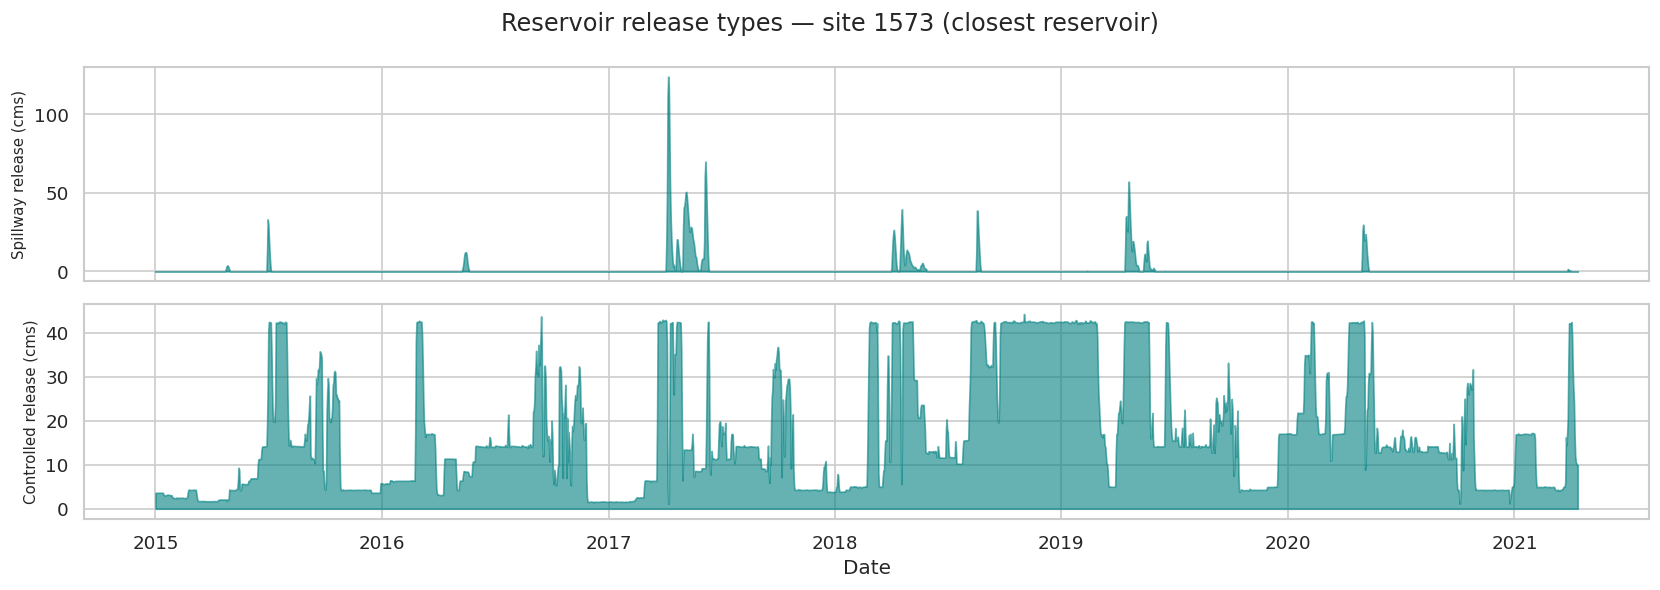

In [8]:
# cols 8 and 9: spillway and controlled releases from the site's closest reservoir
sid = 1573
s = sites[sid]
zoom = s['dates'] >= pd.Timestamp('2015-01-01')
dates_z = s['dates'][zoom]
X_z = s['X'][zoom]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for ax, (col, name) in zip(axes, [(8, 'Spillway release (cms)'), (9, 'Controlled release (cms)')]):
    ax.fill_between(dates_z, X_z[:, col], alpha=0.6, color='teal')
    ax.set_ylabel(name, fontsize=9)
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle(f'Reservoir release types — site {sid} (closest reservoir)')
plt.tight_layout()
plt.show()

## 6. Feature–target correlation heatmap

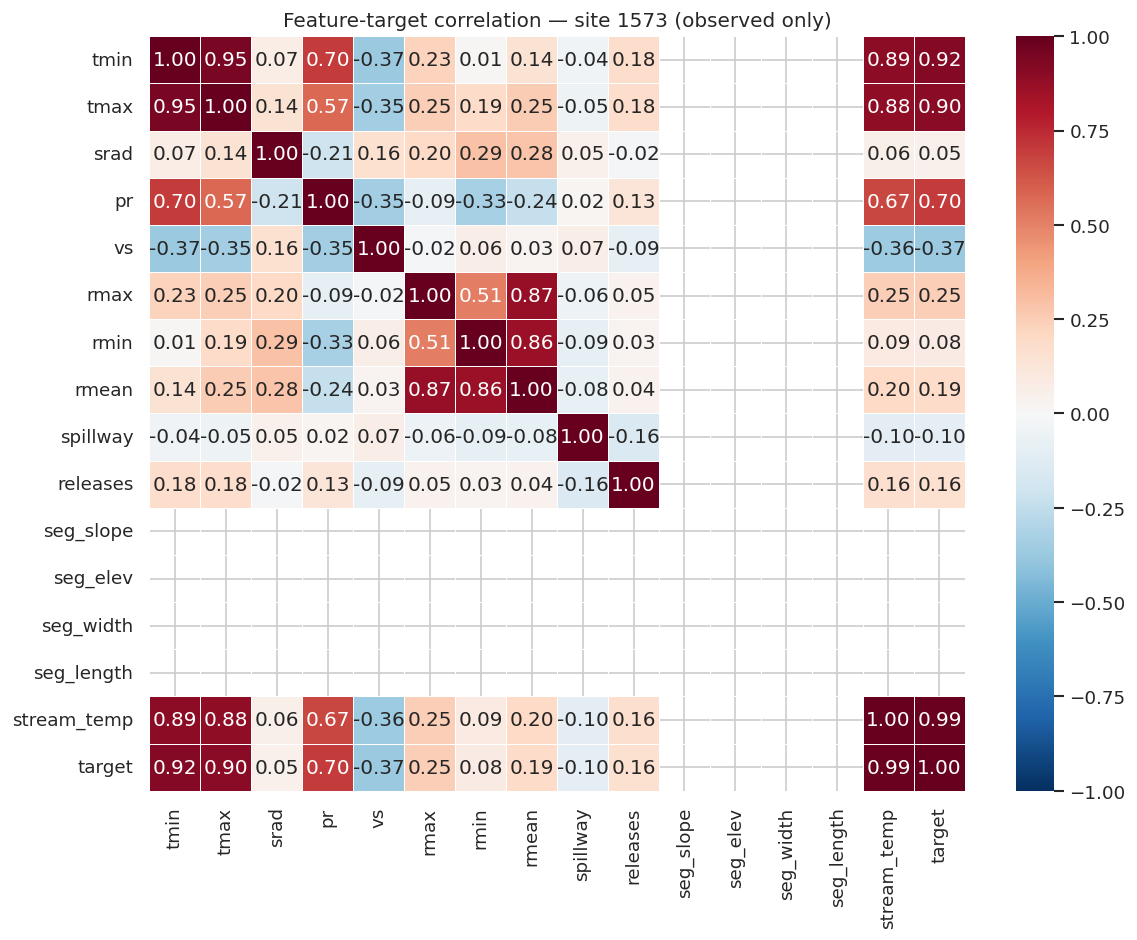


Correlation with target (sorted):
stream_temp    0.990
tmin           0.919
tmax           0.904
pr             0.698
rmax           0.246
rmean          0.191
releases       0.161
rmin           0.082
srad           0.050
spillway      -0.100
vs            -0.375
seg_slope        NaN
seg_elev         NaN
seg_width        NaN
seg_length       NaN


In [9]:
sid = 1573
s = sites[sid]
obs_idx = ~s['mask']  # observed targets only
df_corr = pd.DataFrame(s['X'][obs_idx], columns=FEATURE_NAMES)
df_corr['target'] = s['Y'][obs_idx]

corr = df_corr.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title(f'Feature-target correlation — site {sid} (observed only)')
plt.tight_layout()
plt.show()

print('\nCorrelation with target (sorted):')
print(corr['target'].drop('target').sort_values(ascending=False).round(3).to_string())

## 7. Observed vs infilled targets over time

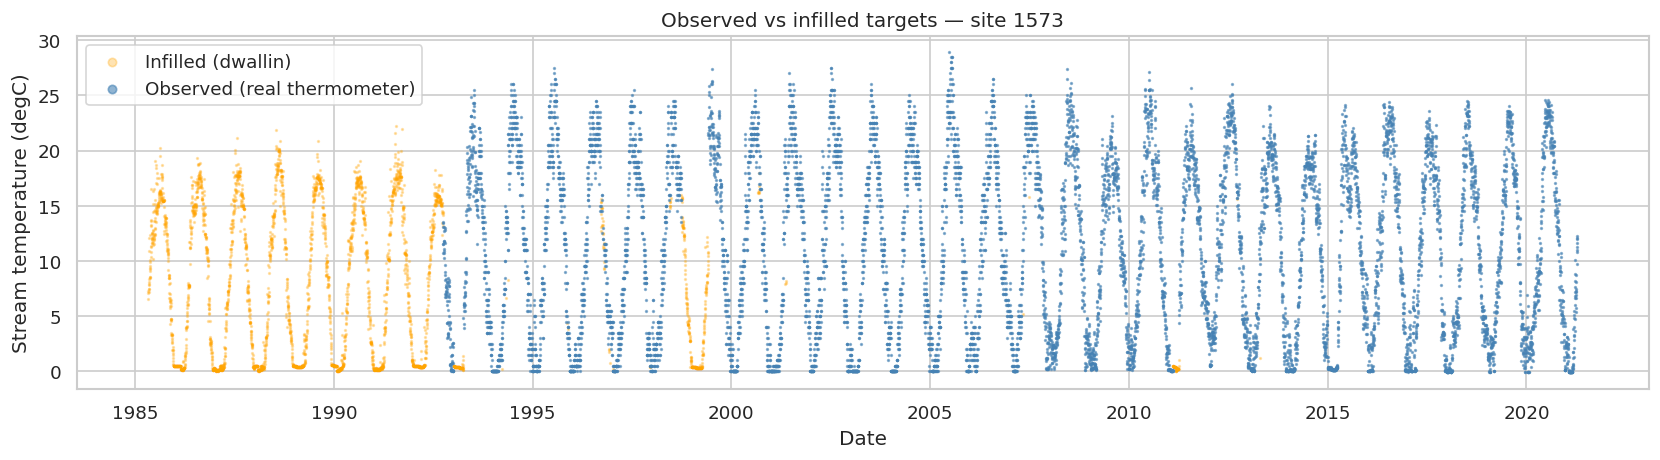

Training options for handling infilled targets:
  (a) Train on all rows (simpler, more data)
  (b) Exclude infilled rows from the loss (finetune_Y_mask=True)
  (c) Weight infilled rows lower than observed rows


In [10]:
sid = 1573
s = sites[sid]
obs_idx = ~s['mask']
inf_idx = s['mask']

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(s['dates'][inf_idx], s['Y'][inf_idx],
           s=1, alpha=0.3, color='orange', label='Infilled (dwallin)')
ax.scatter(s['dates'][obs_idx], s['Y'][obs_idx],
           s=1, alpha=0.6, color='steelblue', label='Observed (real thermometer)')
ax.set_title(f'Observed vs infilled targets — site {sid}')
ax.set_ylabel('Stream temperature (degC)')
ax.set_xlabel('Date')
ax.legend(markerscale=5)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print('Training options for handling infilled targets:')
print('  (a) Train on all rows (simpler, more data)')
print('  (b) Exclude infilled rows from the loss (finetune_Y_mask=True)')
print('  (c) Weight infilled rows lower than observed rows')

## 8. Static site attributes across sites

Columns 10–13 (seg_slope, seg_elev, seg_width, seg_length) are **constant within each site** — they describe the stream segment's physical characteristics and do not change day to day.

In [11]:
# cols 10-13: seg_slope, seg_elev, seg_width, seg_length
static_cols = {'seg_slope': 10, 'seg_elev': 11, 'seg_width': 12, 'seg_length': 13}
rows = []
for sid, s in sites.items():
    row = {'site_id': sid}
    for name, col in static_cols.items():
        row[name] = round(float(s['X'][0, col]), 4)
    rows.append(row)
pd.DataFrame(rows).set_index('site_id')

,seg_slope,seg_elev,seg_width,seg_length
site_id,,,,
1573,0.0008,256.44,49.6863,2511.6096
1571,0.0014,282.46,39.5918,12134.9404
1565,0.0008,292.76,38.8062,10034.7324
1450,0.0013,316.53,37.0810,21972.1758
1641,0.0019,328.93,32.6999,17861.5449
